## Data Loading

In [ ]:
# Import library untuk analisis data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load Dataset
df = pd.read_csv("/content/TPT Provinsi Jawa Tengah.xlsx - Sheet1.csv")
df

,Semester,TPT
0,Februari 2005,8.51
1,Agustus 2005,9.54
2,Februari 2006,8.20
3,Agustus 2006,8.02
4,Februari 2007,8.10
5,Agustus 2007,7.70
6,Februari 2008,7.12
7,Agustus 2008,7.35
8,Februari 2009,7.28
9,Agustus 2009,7.33


In [ ]:
# Mengonversi nama bulan Indonesia menjadi angka bulan
bulan_map = {
    'Januari': 1,
    'Februari': 2,
    'Maret': 3,
    'April': 4,
    'Mei': 5,
    'Juni': 6,
    'Juli': 7,
    'Agustus': 8,
    'September': 9,
    'Oktober': 10,
    'November': 11,
    'Desember': 12
}

# Memisahkan kolom Semester menjadi bulan dan tahun
df[['bulan', 'tahun']] = df['Semester'].str.split(' ', expand=True)

# Mengubah nama bulan menjadi format numerik
df['bulan'] = df['bulan'].map(bulan_map)

# Mengubah tahun menjadi tipe data integer
df['tahun'] = df['tahun'].astype(int)

# Membuat kolom tanggal untuk analisis time series
df['Date'] = pd.to_datetime({
    'year': df['tahun'],
    'month': df['bulan'],
    'day': 1
})

# Memilih kolom yang akan digunakan dalam analisis
df = df[['Date', 'TPT']]

# Menampilkan hasil transformasi data
print(df)

         Date   TPT
0  2005-02-01  8.51
1  2005-08-01  9.54
2  2006-02-01  8.20
3  2006-08-01  8.02
4  2007-02-01  8.10
5  2007-08-01  7.70
6  2008-02-01  7.12
7  2008-08-01  7.35
8  2009-02-01  7.28
9  2009-08-01  7.33
10 2010-02-01  6.86
11 2010-08-01  6.21
12 2011-02-01  6.18
13 2011-08-01  7.07
14 2012-02-01  5.90
15 2012-08-01  5.61
16 2013-02-01  5.53
17 2013-08-01  6.01
18 2014-02-01  5.45
19 2014-08-01  5.68
20 2015-02-01  5.31
21 2015-08-01  4.99
22 2016-02-01  4.20
23 2016-08-01  4.63
24 2017-02-01  4.15
25 2017-08-01  4.57
26 2018-02-01  4.19
27 2018-08-01  4.47
28 2019-02-01  4.19
29 2019-08-01  4.44
30 2020-02-01  4.20
31 2020-08-01  6.48
32 2021-02-01  5.96
33 2021-08-01  5.95
34 2022-02-01  5.75
35 2022-08-01  5.57
36 2023-02-01  5.24
37 2023-08-01  5.13
38 2024-02-01  4.39
39 2024-08-01  4.78
40 2025-02-01  4.33
41 2025-08-01  4.66
42 2026-02-01  4.24


In [ ]:
# Menyiapkan data time series dengan index periode bulanan
df['Date'] = df['Date'].dt.to_period('M')
df = df.set_index('Date')
df

/tmp/ipykernel_3165/2444119833.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = df['Date'].dt.to_period('M')


,TPT
Date,
2005-02,8.51
2005-08,9.54
2006-02,8.20
2006-08,8.02
2007-02,8.10
2007-08,7.70
2008-02,7.12
2008-08,7.35
2009-02,7.28


In [ ]:
# Membersihkan struktur kolom dan membuat dataframe khusus variabel TPT
df.columns = df.columns.get_level_values(0)
TPT = pd.DataFrame(df["TPT"]).rename(columns={"TPT":"tingkat_pengangguran"})
TPT

,tingkat_pengangguran
Date,
2005-02,8.51
2005-08,9.54
2006-02,8.20
2006-08,8.02
2007-02,8.10
2007-08,7.70
2008-02,7.12
2008-08,7.35
2009-02,7.28


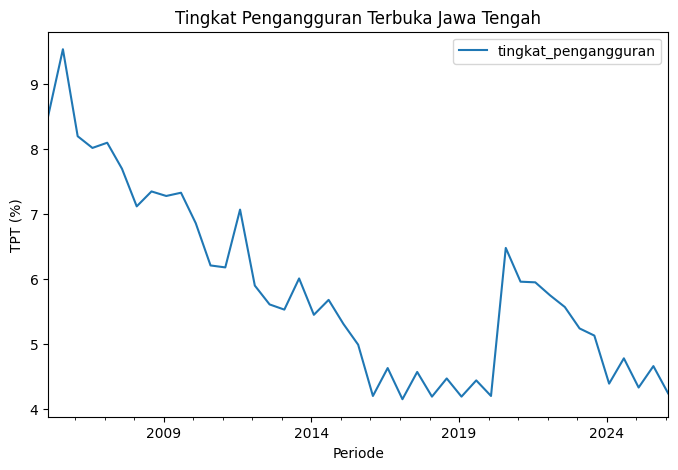

In [ ]:
# Visualisasi tren Tingkat Pengangguran Terbuka (TPT) Jawa Tengah
TPT.plot(figsize=(8, 5))
plt.title("Tingkat Pengangguran Terbuka Jawa Tengah", fontsize=12)
plt.xlabel("Periode")
plt.ylabel("TPT (%)")
plt.legend(fontsize=10, loc="upper right")
plt.show()

### Cek seasonality

In [ ]:
# Mengubah index menjadi format timestamp dan menetapkan frekuensi data setiap 6 bulan
df.index = df.index.to_timestamp()
df = df.asfreq('6MS')
df


,TPT
Date,
2005-02-01,8.51
2005-08-01,9.54
2006-02-01,8.20
2006-08-01,8.02
2007-02-01,8.10
2007-08-01,7.70
2008-02-01,7.12
2008-08-01,7.35
2009-02-01,7.28


In [ ]:
# Menghitung koefisien variasi (CV) TPT pada setiap kelompok periode tahun
df['year'] = df.index.year

cv = df.groupby(pd.cut(df['year'], bins=4))['TPT'].agg(
    mean='mean',
    std='std'
)

cv['cv'] = cv['std'] / cv['mean']

print(cv)

                         mean       std        cv
year                                             
(2004.979, 2010.25]  7.685000  0.865989  0.112686
(2010.25, 2015.5]    5.773000  0.572151  0.099108
(2015.5, 2020.75]    4.552000  0.700346  0.153855
(2020.75, 2026.0]    5.090909  0.652510  0.128172


/tmp/ipykernel_3165/3846903727.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cv = df.groupby(pd.cut(df['year'], bins=4))['TPT'].agg(


Berdasarkan analisis Coefficient of Variation (CV), nilai CV berada pada rentang 0.099–0.154 dan tidak menunjukkan perubahan sistematis seiring perubahan level data. Selain itu, standar deviasi relatif stabil meskipun rata-rata TPT mengalami penurunan dalam jangka panjang. Hal ini mengindikasikan bahwa besarnya fluktuasi tidak bergantung secara proporsional terhadap level data, sehingga karakteristik data lebih sesuai dimodelkan menggunakan pendekatan additive dibandingkan multiplicative.

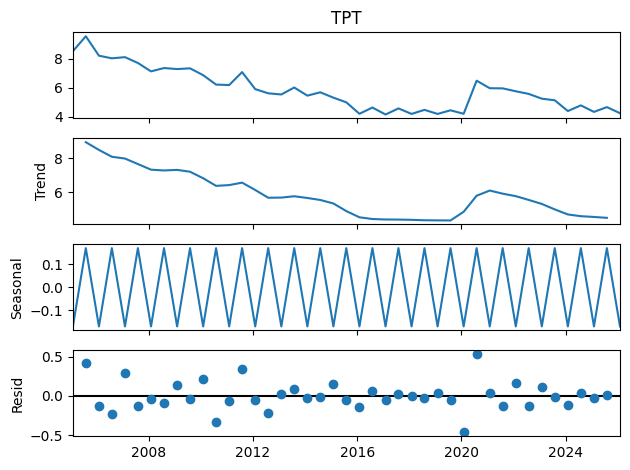

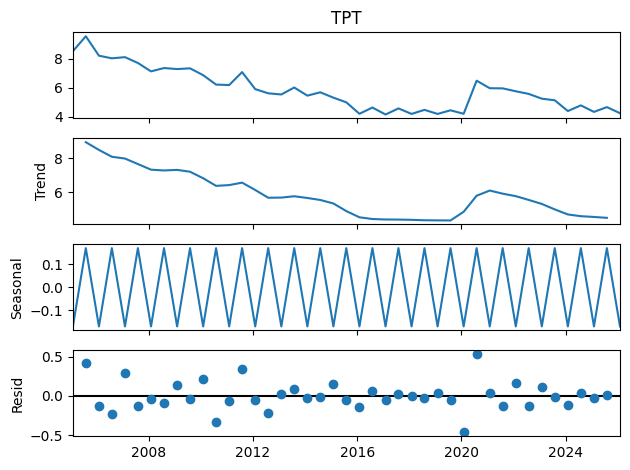

In [ ]:
# Melakukan dekomposisi time series untuk melihat komponen tren, musiman, dan residual
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    df['TPT'],
    model='additive',
    period=2
)

result.plot()

Hasil seasonal decomposition menunjukkan bahwa data TPT memiliki tren penurunan yang cukup kuat dalam jangka panjang. Komponen musiman semesteran terlihat konsisten sepanjang periode pengamatan, namun amplitudonya relatif kecil dibandingkan perubahan trend. Residual tidak menunjukkan pola tertentu sehingga sebagian besar variasi data telah dijelaskan oleh komponen trend dan seasonality. Selain itu, terdapat gangguan sementara sekitar tahun 2020–2021 yang kemungkinan berkaitan dengan dampak pandemi COVID-19 terhadap pasar tenaga kerja.

Dari hasil analisis rekomendasi model yang dapat digunakan adalah model yang dapat menangkap trend tanpa seasonality yang kuat (dapat dilihat jika seasonality dan residual memiliki nilai yang rendah yakni nilai yang mendekati 0, hal tersebut berarti tren sudah menjelaskan isi data)

 ### Stationary Check

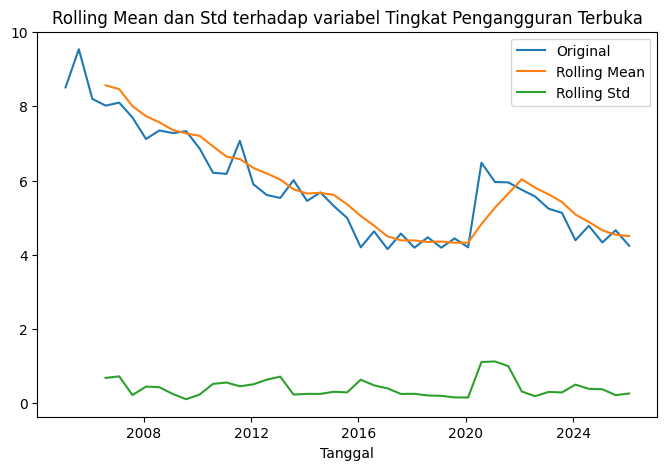

In [ ]:
# Analisis rolling statistics untuk mengevaluasi kestabilan rata-rata dan variasi TPT dari waktu ke waktu
rolling_mean = df['TPT'].rolling(4).mean()
rolling_std = df['TPT'].rolling(4).std()

plt.figure(figsize=(8,5))

plt.plot(df['TPT'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')

plt.title("Rolling Mean dan Std terhadap variabel Tingkat Pengangguran Terbuka")
plt.xlabel("Tanggal")
plt.legend()
plt.show()

Secara Visual, hasil analisis Rolling Mean menunjukkan bahwa rata-rata TPT mengalami perubahan sepanjang periode pengamatan sehingga data belum memenuhi asumsi stationarity pada sisi mean. Terdapat tren penurunan jangka panjang yang cukup kuat serta kenaikan sementara pada periode 2020–2021 yang mengindikasikan adanya shock eksternal. Sementara itu, Rolling Standard Deviation menunjukkan bahwa variabilitas data relatif stabil dan tidak mengalami perubahan sistematis dalam jangka panjang. Peningkatan volatilitas hanya terlihat pada periode 2020–2021 dan kembali normal setelahnya. Secara keseluruhan, data memiliki tren yang kuat namun varians yang relatif stabil.

In [ ]:
# Melakukan uji Augmented Dickey-Fuller (ADF) untuk mengecek stasioneritas data TPT
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['TPT'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.548631939574167
p-value: 0.10408541532629134


### Hipotesis ADF :

H0 (Null Hypothesis) :
- Data memiliki unit root
- Data tidak stationary

H1 (Alternative Hypothesis & p-value < 0.05) :
- Data stationary

Hasil Augmented Dickey-Fuller Test menghasilkan nilai statistik sebesar -2.549 dengan p-value sebesar 0.104. Karena p-value lebih besar dari 0.05, hipotesis nol tidak dapat ditolak sehingga data TPT belum memenuhi asumsi stationarity. Temuan ini konsisten dengan hasil analisis visual sebelumnya yang menunjukkan adanya tren jangka panjang pada data.

## Modelling

### Baseline Model : Naive Forecast

Teknik peramalan sederhana yang mengasumsikan bahwa kondisi atau nilai pada periode berikutnya akan sama persis dengan data aktual pada periode saat ini

In [ ]:
# Mengubah index tanggal dan nilai TPT menjadi array NumPy untuk analisis lanjutan
tanggals = df.index.to_numpy()
tpt = df.TPT.to_numpy()

tanggals[:5], tpt[:5]

(array(['2005-02-01T00:00:00.000000000', '2005-08-01T00:00:00.000000000',
        '2006-02-01T00:00:00.000000000', '2006-08-01T00:00:00.000000000',
        '2007-02-01T00:00:00.000000000'], dtype='datetime64[ns]'),
 array([8.51, 9.54, 8.2 , 8.02, 8.1 ]))

In [ ]:
# Membagi data menjadi data latih (70%) dan data uji (30%)
split_size = int(len(df) * 0.7)

X_train, y_train = tanggals[:split_size], tpt[:split_size]

X_test, y_test = tanggals[split_size:], tpt[split_size:]

len(X_train), len(X_test), len(y_train), len(y_test)

(30, 13, 30, 13)

In [ ]:
# Membuat fungsi visualisasi time series untuk data aktual maupun hasil prediksi
def plot_time_series(timesteps, values, format=".", label=None):
  plt.plot(timesteps, values, format, label=label)
  plt.xlabel("Tanggal")
  plt.ylabel("Tingkat Pengangguran (%)")
  plt.title("Tingkat Pengangguran di Jawa Tengah")
  if label:
    plt.legend(fontsize=10)
  plt.grid(True)

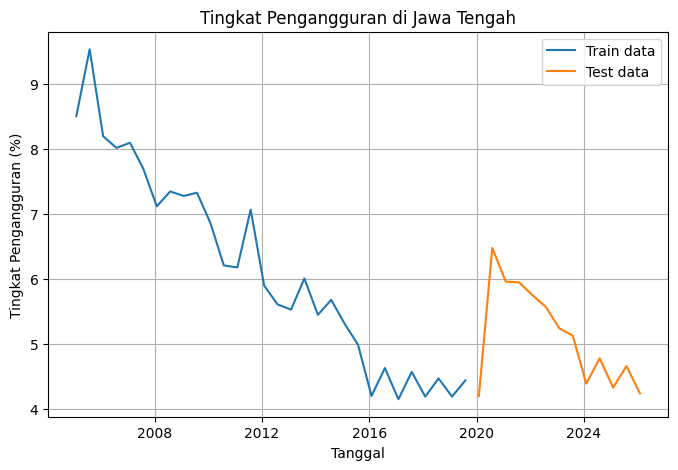

In [ ]:
# Visualisasi data train dan test
plt.figure(figsize=(8, 5))
plot_time_series(timesteps=X_train, values=y_train, format="-", label="Train data")
plot_time_series(timesteps=X_test, values=y_test, format="-",  label="Test data")

In [ ]:
# Membuat baseline forecasting menggunakan metode Naive Forecast
naive_forecast = y_test[:-1]

naive_forecast

array([4.2 , 6.48, 5.96, 5.95, 5.75, 5.57, 5.24, 5.13, 4.39, 4.78, 4.33,
       4.66])

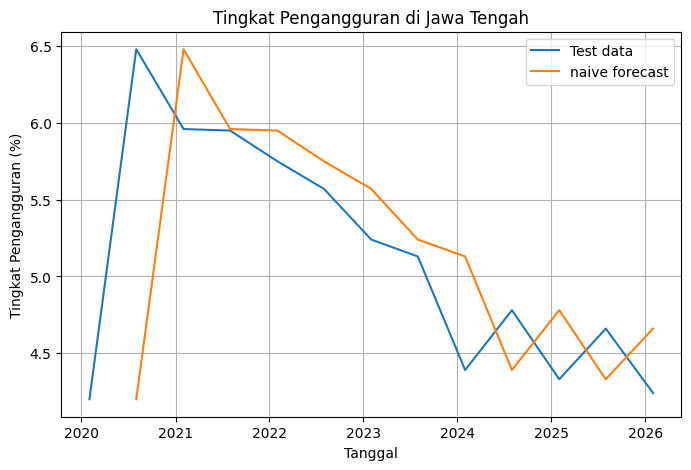

In [ ]:
# Membandingkan data aktual dengan hasil prediksi menggunakan metode Naive Forecast
plt.figure(figsize=(8, 5))
plot_time_series(timesteps=X_test, values=y_test, format="-", label="Test data")
plot_time_series(timesteps=X_test[1:], values=naive_forecast, format="-",  label="naive forecast")

In [ ]:
# Membuat fungsi evaluasi untuk mengukur performa model forecasting
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

def evaluate_forecast(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = mean_absolute_percentage_error(
        y_true, y_pred
    ) * 100

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    }

In [ ]:
# Mengevaluasi performa model Naive Forecast dan menyimpan hasil evaluasi
results = []

results.append(
    evaluate_forecast(
        y_test[1:],
        naive_forecast,
        "Naive"
    )
)

pd.DataFrame(results)

,Model,MAE,RMSE,MAPE (%)
0,Naive,0.496667,0.755524,9.3021


### Model Holt

In [ ]:
# Membangun model Holt Linear Trend untuk menangkap pola tren pada data TPT
from statsmodels.tsa.holtwinters import Holt

holt_fit = Holt(
    y_train,
    exponential=False
).fit()

In [ ]:
holt_fit.params

{'smoothing_level': np.float64(0.6581783618437381),
 'smoothing_trend': np.float64(0.5881603398050874),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(8.51),
 'initial_trend': np.float64(1.0299999999999994),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [ ]:
holt_forecast = holt_fit.forecast(
    len(y_test)
)

In [ ]:
holt_forecast[:5]

array([4.40945979, 4.44977353, 4.49008727, 4.53040101, 4.57071475])

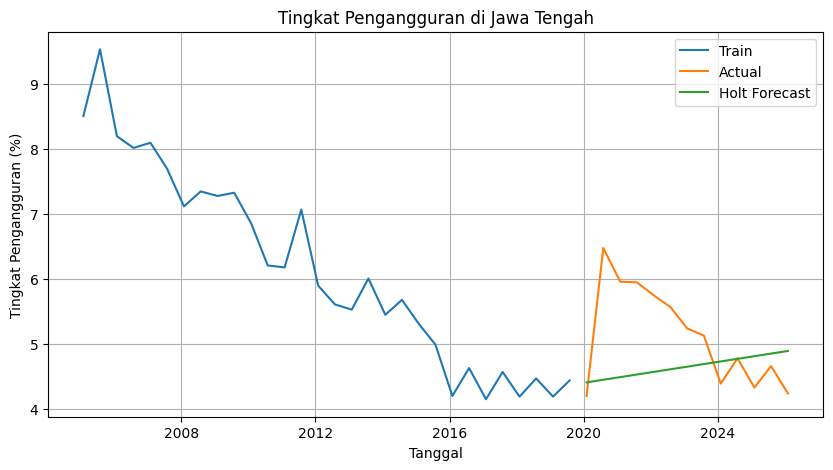

In [ ]:
# Membandingkan data aktual dengan hasil prediksi model Holt pada data uji
plt.figure(figsize=(10,5))

plot_time_series(
    X_train,
    y_train,
    format="-",
    label="Train"
)

plot_time_series(
    X_test,
    y_test,
    format="-",
    label="Actual"
)

plot_time_series(
    X_test,
    holt_forecast,
    format="-",
    label="Holt Forecast"
)

plt.show()

In [ ]:
holt_result = evaluate_forecast(
    y_true=y_test,
    y_pred=holt_forecast,
    model_name="Holt"
)

holt_result

{'Model': 'Holt',
 'MAE': 0.7671442758695173,
 'RMSE': np.float64(0.960945894279974),
 'MAPE (%)': 13.92206249311984}

In [ ]:
results.append(
    evaluate_forecast(
        y_test,
        holt_forecast,
        "Holt"
    )
)

pd.DataFrame(results)

,Model,MAE,RMSE,MAPE (%)
0,Naive,0.496667,0.755524,9.302100
1,Holt,0.767144,0.960946,13.922062


In [ ]:
holt_fitted = holt_fit.fittedvalues

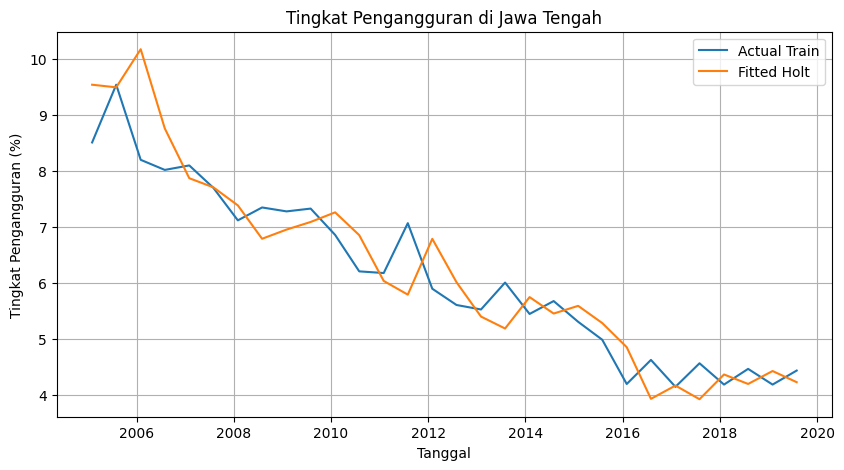

In [ ]:
# Membandingkan data aktual dengan hasil fitting model Holt pada data latih
plt.figure(figsize=(10,5))

plot_time_series(
    X_train,
    y_train,
    format="-",
    label="Actual Train"
)

plot_time_series(
    X_train,
    holt_fitted,
    format="-",
    label="Fitted Holt"
)

plt.show()

Model Holt Linear Trend mampu menangkap pola penurunan jangka panjang pada data TPT dengan baik, yang terlihat dari kesesuaian antara nilai aktual dan fitted values pada data training. Namun performa pada data testing menurun akibat adanya lonjakan pengangguran pada awal periode pengujian yang tidak muncul pada data historis training. Kondisi ini mengindikasikan adanya shock eksternal atau structural break yang tidak dapat diantisipasi oleh model berbasis trend sederhana. Oleh karena itu, evaluasi lanjutan menggunakan ETS dan ARIMA diperlukan untuk mengetahui apakah model yang lebih fleksibel mampu memberikan performa yang lebih baik.

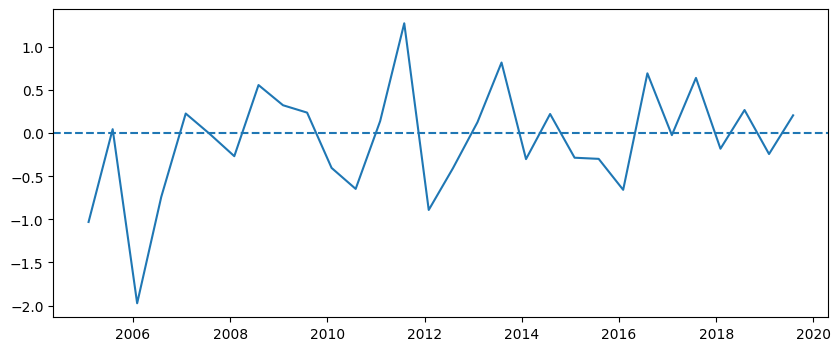

In [ ]:
# Menganalisis residual model Holt untuk mengevaluasi pola kesalahan prediksi
holt_residuals = y_train - holt_fit.fittedvalues

plt.figure(figsize=(10,4))
plt.plot(X_train, holt_residuals)
plt.axhline(0, linestyle='--')
plt.show()

Residual model Holt berfluktuasi di sekitar nol tanpa menunjukkan pola sistematis yang jelas. Hal ini mengindikasikan bahwa model telah berhasil menangkap sebagian besar pola trend pada data. Namun masih terdapat beberapa residual ekstrem pada beberapa periode yang menunjukkan adanya variasi yang belum dapat dijelaskan sepenuhnya oleh model.

### Model ETS ( Exponential Smoothing )

In [ ]:
# Membangun model Exponential Smoothing untuk menangkap pola tren pada data TPT
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_fit = ExponentialSmoothing(
    y_train,
    trend='add',
    seasonal_periods=None
).fit()

In [ ]:
ets_fit.params

{'smoothing_level': np.float64(0.17501982629578133),
 'smoothing_trend': np.float64(0.17501982629578133),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(8.95986677739897),
 'initial_trend': np.float64(-0.20840229777929237),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [ ]:
ets_forecast = ets_fit.forecast(
    len(y_test)
)

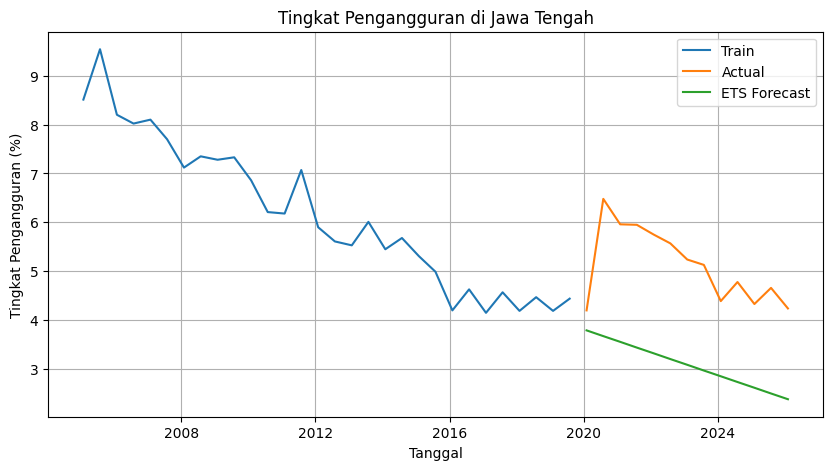

In [ ]:
# Membandingkan data aktual dengan hasil prediksi model Exponential Smoothing pada data uji
plt.figure(figsize=(10,5))

plot_time_series(
    X_train,
    y_train,
    format="-",
    label="Train"
)

plot_time_series(
    X_test,
    y_test,
    format="-",
    label="Actual"
)

plot_time_series(
    X_test,
    ets_forecast,
    format="-",
    label="ETS Forecast"
)

plt.show()

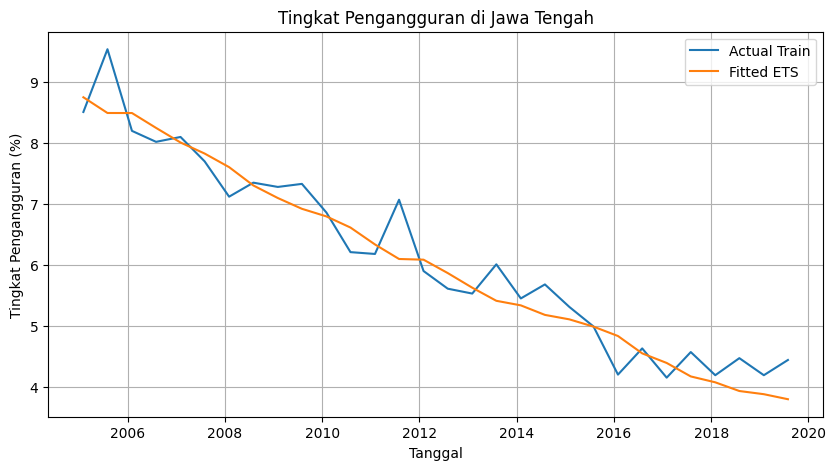

In [ ]:
# Membandingkan data aktual dengan hasil fitting model Exponential Smoothing pada data latih
ets_fitted = ets_fit.fittedvalues

plt.figure(figsize=(10,5))

plot_time_series(
    X_train,
    y_train,
    format="-",
    label="Actual Train"
)

plot_time_series(
    X_train,
    ets_fitted,
    format="-",
    label="Fitted ETS"
)

plt.show()

In [ ]:
# Mengevaluasi performa model Exponential Smoothing (ETS) dan menambahkan hasil ke tabel perbandingan
results.append(
    evaluate_forecast(
        y_test,
        ets_forecast,
        "ETS"
    )
)

pd.DataFrame(results)

,Model,MAE,RMSE,MAPE (%)
0,Naive,0.496667,0.755524,9.302100
1,Holt,0.767144,0.960946,13.922062
2,ETS,2.041646,2.120981,39.294109


In [ ]:
ets_seasonal = ExponentialSmoothing(
    y_train,
    trend='add',
    seasonal='add',
    seasonal_periods=2
).fit()

In [ ]:
ets_seasonal.params

{'smoothing_level': np.float64(0.18789219603631818),
 'smoothing_trend': np.float64(0.18789219603631818),
 'smoothing_seasonal': np.float64(0.0),
 'damping_trend': nan,
 'initial_level': np.float64(8.955823402018567),
 'initial_trend': np.float64(-0.2145907426215922),
 'initial_seasons': array([-0.11738202,  0.21370539]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [ ]:
ets_seasonal_forecast = ets_seasonal.forecast(
    len(y_test)
)

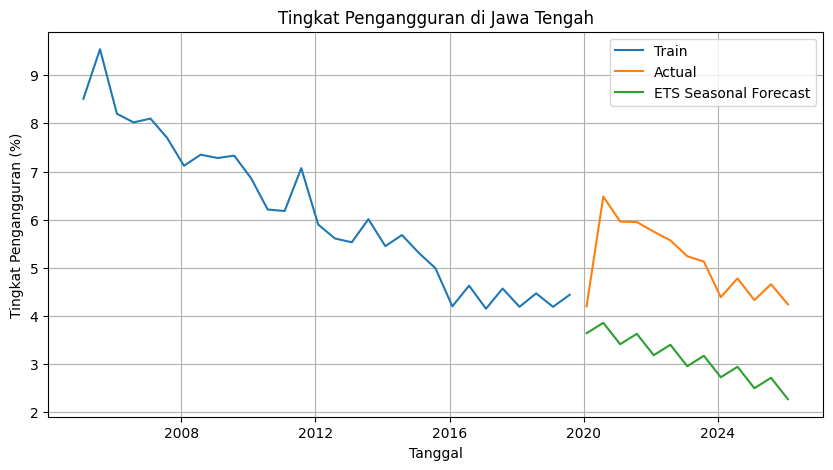

In [ ]:
# Membandingkan data aktual dengan hasil prediksi model ETS Seasonal pada data u
plt.figure(figsize=(10,5))

plot_time_series(
    X_train,
    y_train,
    format="-",
    label="Train"
)

plot_time_series(
    X_test,
    y_test,
    format="-",
    label="Actual"
)

plot_time_series(
    X_test,
    ets_seasonal_forecast,
    format="-",
    label="ETS Seasonal Forecast"
)

plt.show()

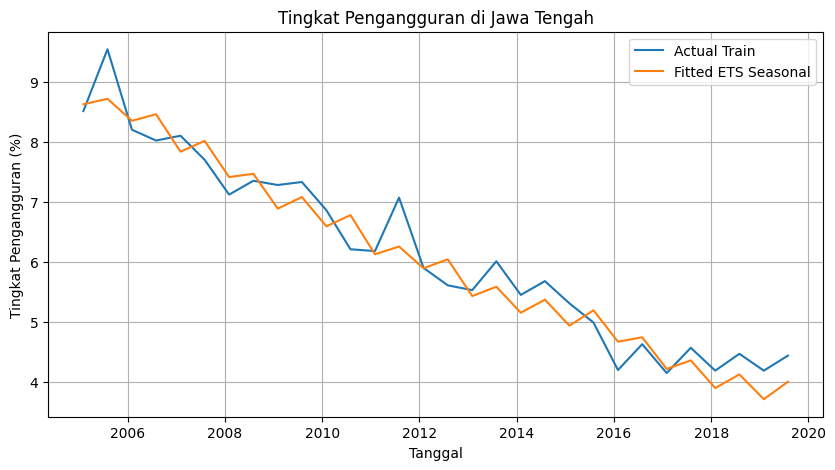

In [ ]:
# Membandingkan data aktual dengan hasil fitting model ETS Seasonal pada data latih
ets_seasonal_fitted = ets_seasonal.fittedvalues

plt.figure(figsize=(10,5))

plot_time_series(
    X_train,
    y_train,
    format="-",
    label="Actual Train"
)

plot_time_series(
    X_train,
    ets_seasonal_fitted,
    format="-",
    label="Fitted ETS Seasonal"
)

plt.show()

In [ ]:
# Menampilkan hasil evaluasi seluruh model forecasting
results.append(
    evaluate_forecast(
        y_test,
        ets_seasonal_forecast,
        "ETS Seasonal"
    )
)

pd.DataFrame(results)

,Model,MAE,RMSE,MAPE (%)
0,Naive,0.496667,0.755524,9.302100
1,Holt,0.767144,0.960946,13.922062
2,ETS,2.041646,2.120981,39.294109
3,ETS Seasonal,2.020246,2.085170,39.035187


Model ETS dan ETS Seasonal menunjukkan performa yang jauh lebih rendah dibandingkan Naive Forecast. Hal ini terjadi karena kedua model mempelajari tren penurunan pengangguran yang sangat kuat pada data historis dan mengasumsikan tren tersebut akan terus berlanjut pada periode forecasting. Namun pada awal periode pengujian terjadi peningkatan pengangguran yang signifikan akibat faktor eksternal yang tidak terdapat pada data training. Selain itu, nilai smoothing seasonal sebesar 0 menunjukkan bahwa komponen musiman tidak memberikan kontribusi yang berarti terhadap proses forecasting. Dengan demikian, kegagalan model bukan disebabkan oleh ketidakmampuan menangkap pola historis, melainkan karena adanya perubahan struktural yang tidak dapat diantisipasi oleh model berbasis tren dan musiman.

### Model ARIMA

Differencing

In [ ]:
df['TPT_diff'] = df['TPT'].diff()
df.head()

,TPT,year,TPT_diff
Date,,,
2005-02-01,8.51,2005,NaN
2005-08-01,9.54,2005,1.03
2006-02-01,8.20,2006,-1.34
2006-08-01,8.02,2006,-0.18
2007-02-01,8.10,2007,0.08


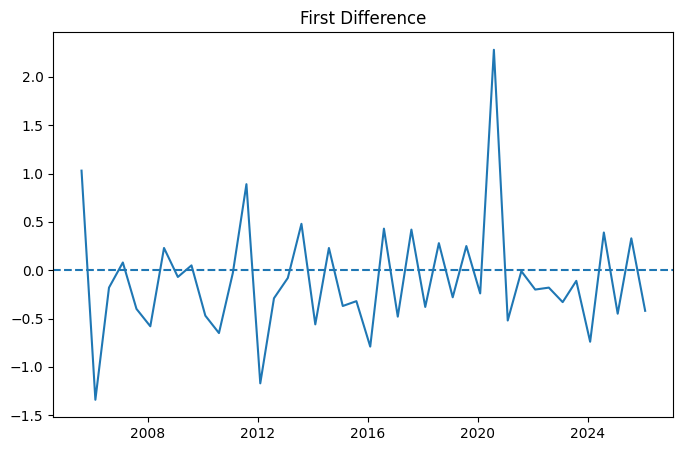

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    df.index,
    df['TPT_diff']
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title("First Difference")
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(
    df['TPT_diff'].dropna()
)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -9.70148556525986
p-value: 1.0692720266778935e-16


Setelah dilakukan differencing satu kali, nilai ADF Statistic berubah dari -2.549 menjadi -9.701 dan p-value turun dari 0.104 menjadi 1.06×10⁻¹⁶. Hasil ini menunjukkan bahwa differencing berhasil menghilangkan trend pada data sehingga data menjadi stationary. Oleh karena itu, jumlah differencing yang diperlukan untuk model ARIMA adalah satu kali (d = 1).

Mencari nilai p (berapa data yang benar-benar berpengaruh untuk prediksi selanjutnya) dan q (berapa lag yang benar-benar berpengaruh)

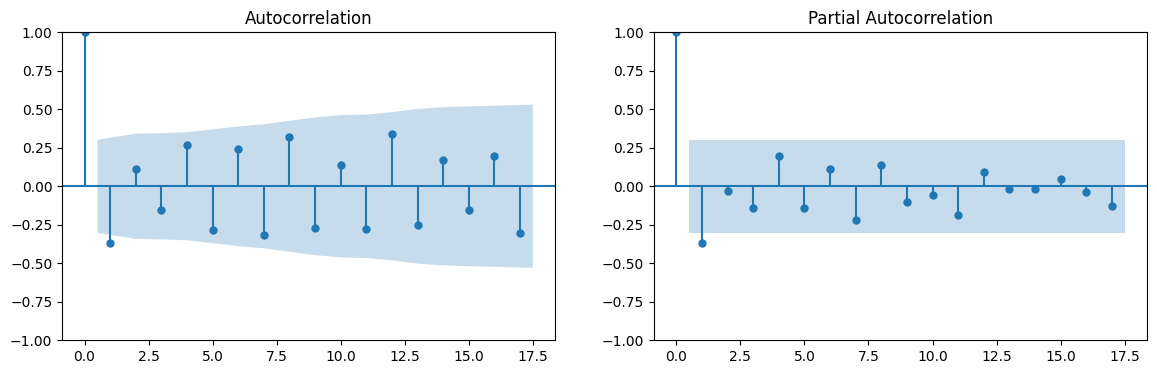

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(1, 2, figsize=(14,4))

plot_acf(
    df['TPT_diff'].dropna(),
    ax=ax[0]
)

plot_pacf(
    df['TPT_diff'].dropna(),
    ax=ax[1]
)

plt.show()

Hasil differencing pertama menghasilkan data yang sudah stationary dengan p-value ADF sebesar 1.06×10⁻¹⁶. Pada plot PACF terlihat hanya lag ke-1 yang signifikan, sedangkan lag lainnya berada dalam batas kepercayaan. Hal yang sama juga terlihat pada plot ACF, di mana hanya lag ke-1 yang menunjukkan korelasi yang signifikan. Temuan ini menunjukkan bahwa ketergantungan jangka pendek pada satu periode sebelumnya masih terdapat dalam data, sehingga kandidat model yang layak diuji adalah ARIMA(1,1,0), ARIMA(0,1,1), dan ARIMA(1,1,1).

ARIMA (1,1,1)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    y_train,
    order=(1,1,1) # order=(p,d,q)
)

arima_fit = arima_model.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   30
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -22.019
Date:                Mon, 01 Jun 2026   AIC                             50.038
Time:                        10:03:04   BIC                             54.140
Sample:                             0   HQIC                            51.323
                                 - 30                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2777      0.624     -0.445      0.656      -1.501       0.945
ma.L1         -0.0835      0.711     -0.118      0.906      -1.477       1.310
sigma2         0.2661      0.088      3.033      0.0

In [ ]:
arima_forecast = arima_fit.forecast(
    steps=len(y_test)
)

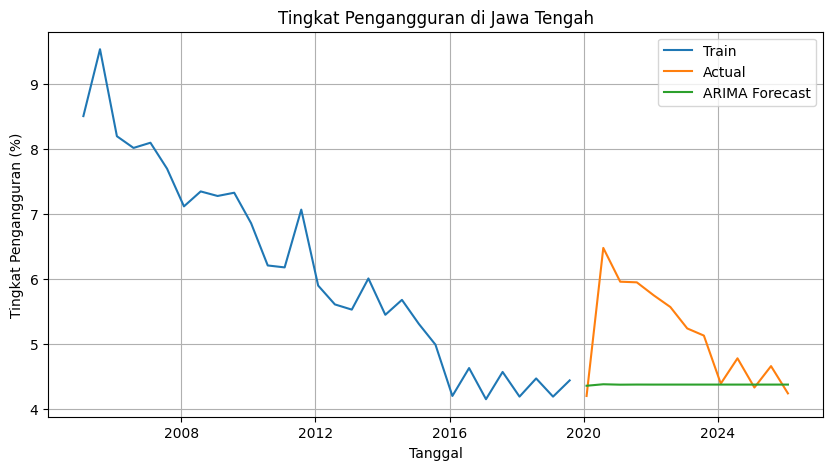

In [ ]:
plt.figure(figsize=(10,5))

plot_time_series(
    X_train,
    y_train,
    format="-",
    label="Train"
)

plot_time_series(
    X_test,
    y_test,
    format="-",
    label="Actual"
)

plot_time_series(
    X_test,
    arima_forecast,
    format="-",
    label="ARIMA Forecast"
)

plt.show()

In [ ]:
results.append(evaluate_forecast(
    y_test,
    arima_forecast,
    "ARIMA(1,1,1)"
))

pd.DataFrame(results)

,Model,MAE,RMSE,MAPE (%)
0,Naive,0.496667,0.755524,9.302100
1,Holt,0.767144,0.960946,13.922062
2,ETS,2.041646,2.120981,39.294109
3,ETS Seasonal,2.020246,2.085170,39.035187
4,"ARIMA(1,1,1)",0.806935,1.049732,14.225028


ARIMA (1,1,0)

In [ ]:
arima_model_2 = ARIMA(
    y_train,
    order=(1,1,0) # order=(p,d,q)
)

arima_fit_2 = arima_model_2.fit()
print(arima_fit_2.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   30
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 -22.031
Date:                Mon, 01 Jun 2026   AIC                             48.061
Time:                        10:03:04   BIC                             50.796
Sample:                             0   HQIC                            48.918
                                 - 30                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3552      0.141     -2.511      0.012      -0.633      -0.078
sigma2         0.2663      0.085      3.148      0.002       0.100       0.432
Ljung-Box (L1) (Q):                   1.16   Jarque-

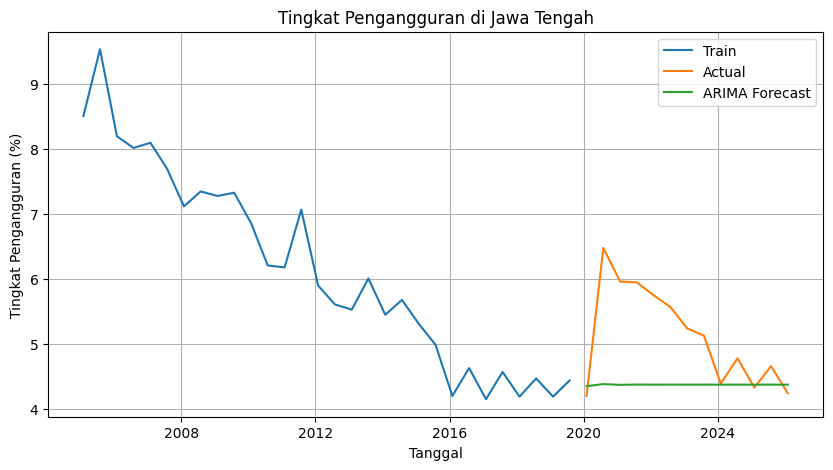

In [ ]:
arima_forecast_2 = arima_fit_2.forecast(
    steps=len(y_test)
)

plt.figure(figsize=(10,5))

plot_time_series(
    X_train,
    y_train,
    format="-",
    label="Train"
)

plot_time_series(
    X_test,
    y_test,
    format="-",
    label="Actual"
)

plot_time_series(
    X_test,
    arima_forecast_2,
    format="-",
    label="ARIMA Forecast"
)

plt.show()

In [ ]:
results.append(evaluate_forecast(
    y_test,
    arima_forecast_2,
    "ARIMA(1,1,0)"
))

pd.DataFrame(results)

,Model,MAE,RMSE,MAPE (%)
0,Naive,0.496667,0.755524,9.302100
1,Holt,0.767144,0.960946,13.922062
2,ETS,2.041646,2.120981,39.294109
3,ETS Seasonal,2.020246,2.085170,39.035187
4,"ARIMA(1,1,1)",0.806935,1.049732,14.225028
5,"ARIMA(1,1,0)",0.806872,1.049982,14.221439


ARIMA (0,1,1)

In [ ]:
arima_model_3 = ARIMA(
    y_train,
    order=(1,1,0) # order=(p,d,q)
)

arima_fit_3 = arima_model_3.fit()
print(arima_fit_3.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   30
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 -22.031
Date:                Mon, 01 Jun 2026   AIC                             48.061
Time:                        10:03:05   BIC                             50.796
Sample:                             0   HQIC                            48.918
                                 - 30                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3552      0.141     -2.511      0.012      -0.633      -0.078
sigma2         0.2663      0.085      3.148      0.002       0.100       0.432
Ljung-Box (L1) (Q):                   1.16   Jarque-

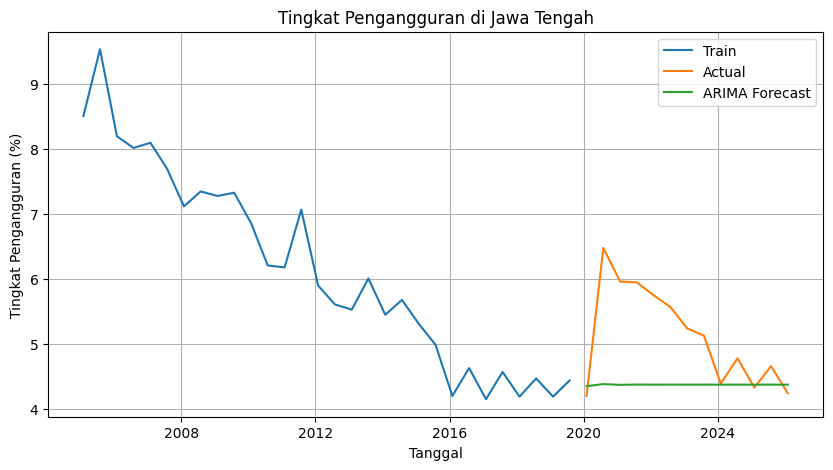

In [ ]:
arima_forecast_3 = arima_fit_3.forecast(
    steps=len(y_test)
)

plt.figure(figsize=(10,5))

plot_time_series(
    X_train,
    y_train,
    format="-",
    label="Train"
)

plot_time_series(
    X_test,
    y_test,
    format="-",
    label="Actual"
)

plot_time_series(
    X_test,
    arima_forecast_3,
    format="-",
    label="ARIMA Forecast"
)

plt.show()

In [ ]:
results.append(evaluate_forecast(
    y_test,
    arima_forecast_3,
    "ARIMA(0,1,1)"
))

pd.DataFrame(results)

,Model,MAE,RMSE,MAPE (%)
0,Naive,0.496667,0.755524,9.302100
1,Holt,0.767144,0.960946,13.922062
2,ETS,2.041646,2.120981,39.294109
3,ETS Seasonal,2.020246,2.085170,39.035187
4,"ARIMA(1,1,1)",0.806935,1.049732,14.225028
5,"ARIMA(1,1,0)",0.806872,1.049982,14.221439
6,"ARIMA(0,1,1)",0.806872,1.049982,14.221439


Berdasarkan hasil eksperimen, model Naive Forecast menghasilkan performa terbaik dengan RMSE 0.756 dan MAPE 9.30%, mengungguli Holt, ETS, maupun ARIMA. Hasil ini menunjukkan bahwa data pengangguran pada periode pengujian mengalami perubahan struktural yang tidak tercermin pada data historis pelatihan. Model berbasis trend (Holt, ETS) maupun model berbasis autocorrelation (ARIMA) cenderung melanjutkan pola historis penurunan pengangguran sehingga gagal mengantisipasi lonjakan yang terjadi pada awal periode pengujian. Temuan ini mengindikasikan bahwa faktor eksternal seperti pandemi COVID-19 memiliki pengaruh yang jauh lebih besar dibandingkan pola historis yang terdapat dalam data.

Final Model

In [ ]:
from statsmodels.tsa.holtwinters import Holt

holt_final = Holt(
    df['TPT'],
    exponential=False
).fit()

In [ ]:
holt_final.params

{'smoothing_level': np.float64(0.7015517599519872),
 'smoothing_trend': np.float64(0.456344873804941),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(8.51),
 'initial_trend': np.float64(1.0299999999999994),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [ ]:
future_steps = 10

forecast_holt = holt_final.forecast(future_steps)

forecast_holt

,0
2026-08-01,4.188837
2027-02-01,4.072306
2027-08-01,3.955775
2028-02-01,3.839244
2028-08-01,3.722713
2029-02-01,3.606182
2029-08-01,3.489651
2030-02-01,3.373119
2030-08-01,3.256588
2031-02-01,3.140057


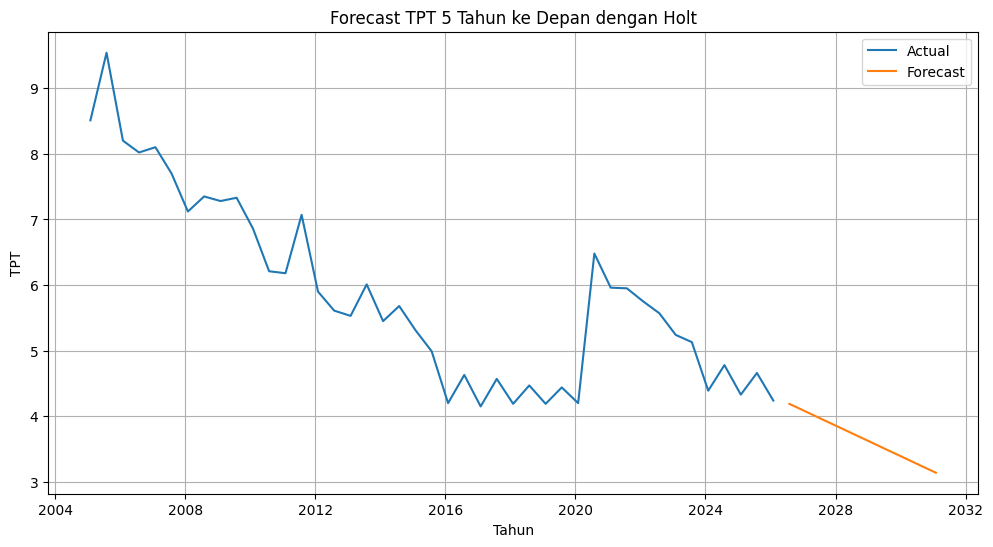

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    df.index,
    df['TPT'],
    label='Actual'
)

plt.plot(
    forecast_holt.index,
    forecast_holt,
    label='Forecast'
)

plt.title("Forecast TPT 5 Tahun ke Depan dengan Holt")
plt.xlabel("Tahun")
plt.ylabel("TPT")
plt.legend()
plt.grid(True)

plt.show()

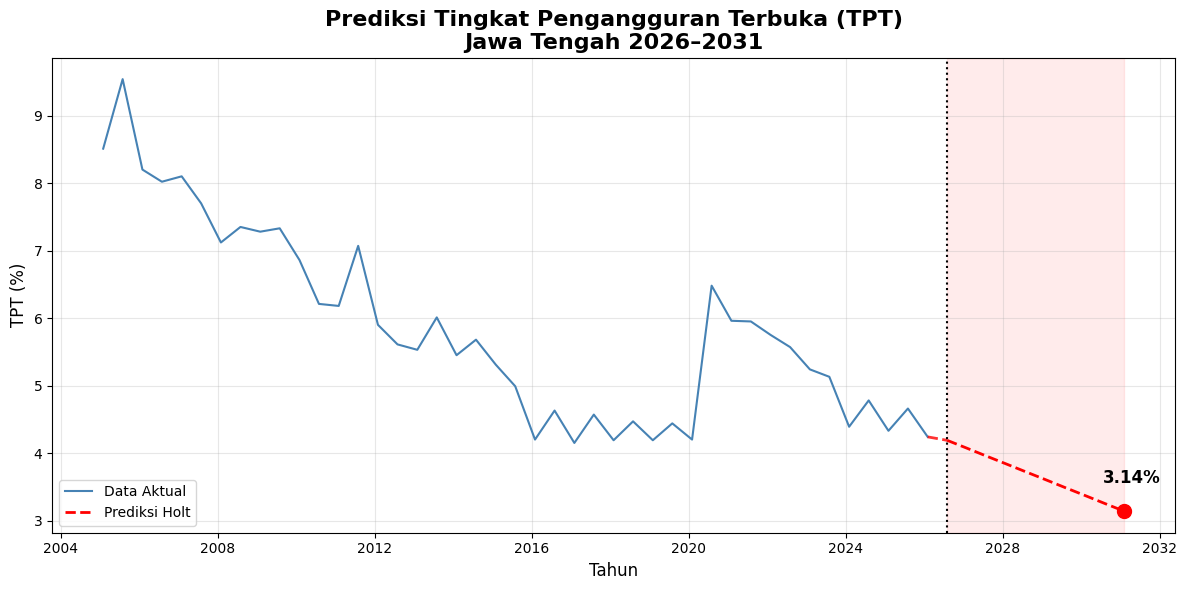

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    df.index,
    df['TPT'],
    color='steelblue',
    linewidth=1.5,
    label='Data Aktual'
)

plt.plot(
    [df.index[-1], forecast_holt.index[0]],
    [df['TPT'].iloc[-1], forecast_holt.iloc[0]],
    color='red',
    linestyle='--',
    alpha=0.8,
    linewidth=2
)

plt.plot(
    forecast_holt.index,
    forecast_holt,
    color='red',
    linewidth=2,
    linestyle='--',
    label='Prediksi Holt'
)

plt.axvspan(
    forecast_holt.index[0],
    forecast_holt.index[-1],
    color='red',
    alpha=0.08
)

plt.axvline(
    forecast_holt.index[0],
    color='black',
    linestyle=':',
    linewidth=1.5
)

# plt.text(
#     forecast_holt.index[0],
#     plt.ylim()[1]*0.98,
#     'Mulai Prediksi',
#     ha='left'
# )

plt.title(
    'Prediksi Tingkat Pengangguran Terbuka (TPT)\nJawa Tengah 2026–2031',
    fontsize=16,
    weight='bold'
)

plt.xlabel('Tahun', fontsize=12)
plt.ylabel('TPT (%)', fontsize=12)

plt.legend()
plt.grid(alpha=0.3)

plt.scatter(
    forecast_holt.index[-1],
    forecast_holt.iloc[-1],
    s=100,
    color='red'
)

plt.annotate(
    f"{forecast_holt.iloc[-1]:.2f}%",
    xy=(forecast_holt.index[-1], forecast_holt.iloc[-1]),
    xytext=(-15,20),
    textcoords='offset points',
    fontsize=12,
    weight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
holt_fitted_forcast = holt_final.fittedvalues

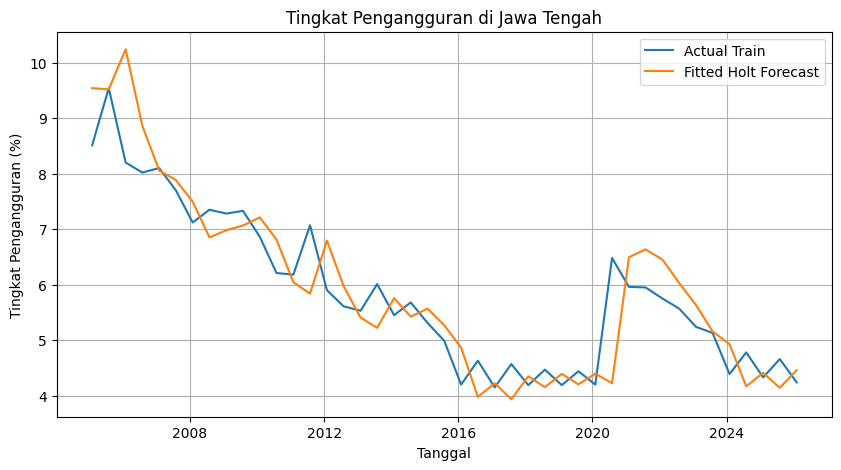

In [ ]:
plt.figure(figsize=(10,5))

plot_time_series(
    df.index,
    df['TPT'],
    format="-",
    label="Actual Train"
)

plot_time_series(
    df.index,
    holt_fitted_forcast,
    format="-",
    label="Fitted Holt Forecast"
)

plt.show()